In [355]:
import sys
from pathlib import Path

project_root = Path.cwd().parents[2]
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [356]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [357]:
import numpy as np
import tsplib95

from clonalg.antibody.permutation_antibody import (
    PermutationAntibody,
    PermutationAntibodyBuilder,
)
from clonalg.model.clonalg_optimization import OptimizationClonalg
from clonalg.problems.problem import Rastrigin
from clonalg.visualization.visualization import plot_3d_surface, plot_contour_and_paths

In [358]:
def gap(found: float, optimal: int) -> float:
    return (found - optimal) / optimal * 100

In [359]:
def load_solutions(filepath: str) -> dict[str, int]:
    solutions = {}
    for line in Path(filepath).read_text().splitlines():
        line = line.strip()
        if not line or line.startswith("#"):
            continue

        name, _, rest = line.partition(":")
        solutions[name.strip().lower()] = int(rest.strip())
    return solutions


solutions = load_solutions("./data/solutions")

In [360]:
import matplotlib.pyplot as plt
import numpy as np


def plot_tsp(coords: np.ndarray, tour: np.ndarray, title: str = "TSP solution"):
    # coords: array (n, 2) with x, y positions
    # tour: array of city indices (without depot)
    full_tour = np.concatenate(([0], tour, [0]))  # close the loop

    fig, ax = plt.subplots(figsize=(8, 6))

    # draw edges
    for i in range(len(full_tour) - 1):
        a, b = full_tour[i], full_tour[i + 1]
        ax.plot(
            [coords[a, 0], coords[b, 0]],
            [coords[a, 1], coords[b, 1]],
            "b-",
            linewidth=0.8,
            alpha=0.6,
        )

    # draw cities
    ax.scatter(coords[:, 0], coords[:, 1], c="red", s=20, zorder=3)

    # label cities
    for i, (x, y) in enumerate(coords):
        ax.annotate(str(i), (x, y), fontsize=7, ha="right")

    ax.set_title(title)
    plt.tight_layout()
    plt.show()

In [361]:
def tour_cost(tour: np.ndarray, problem: tsplib95.models.StandardProblem) -> int:
    n = len(tour)
    return sum(
        problem.get_weight(int(tour[i]), int(tour[(i + 1) % n])) for i in range(n)
    )

In [362]:
def tour_edges(genes: np.ndarray) -> set[frozenset[int]]:
    tour = np.concatenate(([1], genes))
    n = len(tour)
    return {frozenset((int(tour[i]), int(tour[(i + 1) % n]))) for i in range(n)}


def edge_distance(a: np.ndarray, b: np.ndarray) -> int:
    "Number of edges present in tour `a` but not in tour `b` (TSP-aware, symmetric, rotation/reflection invariant)."
    return len(tour_edges(a) - tour_edges(b))

In [363]:
PROBLEM_NAME = "bayg29"

problem = tsplib95.load(f"./data/{PROBLEM_NAME}.tsp")
problem.dimension  # cities are labeled from 1 to N

29

In [364]:
n_cities = problem.dimension
bounds = [(2, problem.dimension)] * (n_cities - 1)


def factory() -> PermutationAntibody:
    genes = np.random.permutation(np.arange(2, n_cities + 1))
    return (
        PermutationAntibodyBuilder()
        .with_genes(genes)
        .with_cost_fn(lambda g: tour_cost(np.concatenate(([1], g)), problem))
        .with_distance_fn(edge_distance)
        .build()
    )

In [365]:
config = {
    "pr124": {
        "population_size": 80,
        "clone_factor": 0.15,
        "rho": 5.0,
        "suppression_threshold": 4.0,
        "antibody_factory": factory,
        "n_generations": 1000,
    },
    "berlin52": {
        "population_size": 40,
        "clone_factor": 0.3,
        "rho": 3.0,
        "suppression_threshold": 2.0,
        "antibody_factory": factory,
        "n_generations": 1000,
    },
    "bays29": {
        "population_size": 20,
        "clone_factor": 0.2,
        "rho": 3.0,
        "suppression_threshold": 2.0,
        "antibody_factory": factory,
        "n_generations": 1000,
    },
    "bayg29": {
        "population_size": 20,
        "clone_factor": 0.2,
        "rho": 3.0,
        "suppression_threshold": 2.0,
        "antibody_factory": factory,
        "n_generations": 1000,
    },
}

In [366]:
clonalg = OptimizationClonalg(**config[PROBLEM_NAME])

memory = clonalg.run()
memory.sort(key=lambda ab: ab.affinity(None), reverse=True)

100%|██████████| 1000/1000 [00:35<00:00, 27.85it/s]


In [367]:
best = memory[0]
best_tour = np.concatenate(([1], best.genes))

print(f"Tour cost = {tour_cost(best_tour, problem)}")
print(f"Best tour cost = {solutions[PROBLEM_NAME]}")

print(f"Affinity = {best.affinity(None):.6f}")
print(
    f"Gap from optimal: {gap(tour_cost(best_tour, problem), solutions[PROBLEM_NAME]):.2f}%"
)

Tour cost = 1630
Best tour cost = 1610
Affinity = 0.000613
Gap from optimal: 1.24%


In [368]:
tour_cost(best_tour, problem)

1630

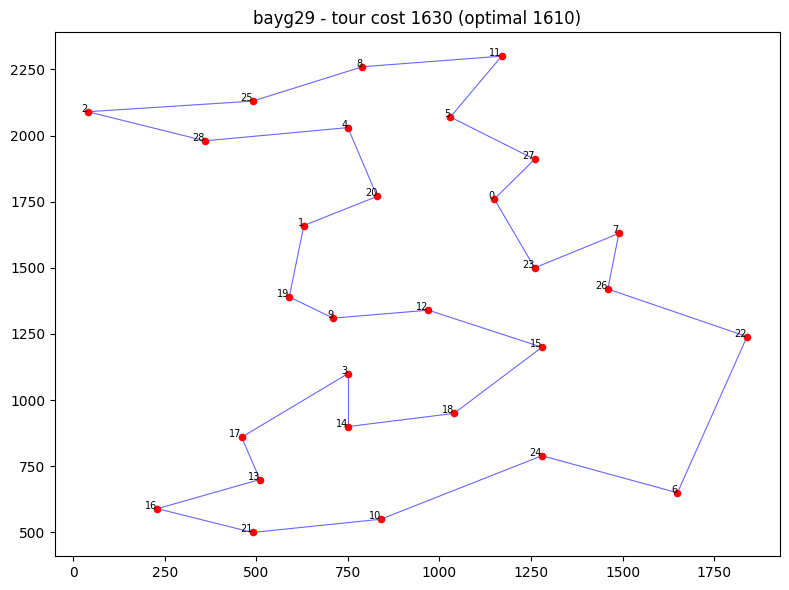

In [369]:
coords_dict = problem.node_coords or problem.display_data
if not coords_dict:
    raise ValueError(f"{PROBLEM_NAME} nie ma współrzędnych do narysowania")

coords = np.array([coords_dict[i + 1] for i in range(n_cities)])
plot_tsp(
    coords,
    best.genes - 1,
    title=f"{PROBLEM_NAME} - tour cost {tour_cost(best_tour, problem)} (optimal {solutions[PROBLEM_NAME]})",
)